In [2]:
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np

from coffea.nanoevents import NanoEventsFactory, ScoutingNanoAODSchema
from coffea.analysis_tools import PackedSelection

import dask_awkward as dak

import itertools as iter

import hist
from hist import Hist
import hist.dask as hda

import vector as vec

import numba

In [3]:
file_list = [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0000.txt").readlines()] + [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0001.txt").readlines()] + [line.strip('\n') for line in open("filelists/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8_0002.txt").readlines()]
file_list = ["root://cmseos.fnal.gov//" + string for string in file_list]



ScoutingNanoAODSchema.warn_missing_crossrefs = False

small_events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list[0:5]},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "HadronicTops"},
).events()

/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/coffea/nanoevents/methods/candidate.py:11: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [4]:
small_events.ScoutingPFJet.fields

['HFEMMultiplicity',
 'HFHadronMultiplicity',
 'chargedHadronMultiplicity',
 'electronMultiplicity',
 'muonMultiplicity',
 'neutralHadronMultiplicity',
 'photonMultiplicity',
 'HFEMEnergy',
 'HFHadronEnergy',
 'HOEnergy',
 'chargedHadronEnergy',
 'csv',
 'electronEnergy',
 'eta',
 'jetArea',
 'm',
 'muonEnergy',
 'neutralHadronEnergy',
 'phi',
 'photonEnergy',
 'pt']

In [9]:
small_events.ScoutingJet.particleNet_prob_b.compute()

<Array [[1.2e-24, 0, 2.82e-25, ..., 0, 0], ...] type='610572 * var * float3...'>

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


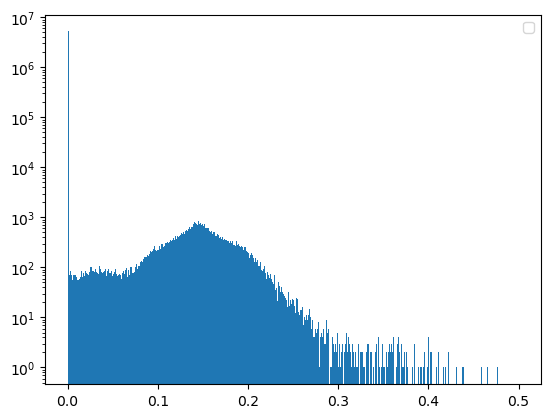

In [5]:
plt.hist(
    ak.flatten(small_events.ScoutingJet.particleNet_prob_b).compute(),
    bins= 500,
    range=(0,0.5)
    )

#y axis is in pico-barns, need to multiply by luminosity to get num events
#lum in inverse pico-barns
plt.yscale('log')
plt.legend()

In [8]:
ak.num(small_events, axis=0).compute()

610572

In [7]:
jet_cut = small_events.ScoutingJet.particleNet_prob_b < 0.001 
ak.num(small_events.ScoutingJet[jet_cut]).compute()

<Array [6, 6, 6, 6, 9, 4, 3, ..., 5, 18, 8, 17, 6, 18] type='610572 * int64'>

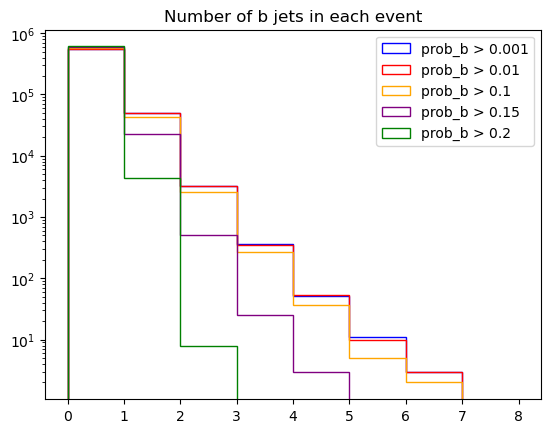

In [6]:
#cut_ev = small_events[(ak.num(small_events.ScoutingJet) >= 4)]

plt.hist(
    ak.sum(small_events.ScoutingJet.particleNet_prob_b > 0.001 ,axis=1).compute(),
    bins= 8,
    range=(0,8),
    histtype='step',
    color="blue",
    label="prob_b > 0.001"
    )
plt.hist(
    ak.sum(small_events.ScoutingJet.particleNet_prob_b > 0.01 ,axis=1).compute(),
    bins= 8,
    range=(0,8),
    histtype='step',
    color="red",
    label="prob_b > 0.01"
    )
plt.hist(
    ak.sum(small_events.ScoutingJet.particleNet_prob_b > 0.1 ,axis=1).compute(),
    bins= 8,
    range=(0,8),
    histtype='step',
    color="orange",
    label="prob_b > 0.1"
    )
plt.hist(
    ak.sum(small_events.ScoutingJet.particleNet_prob_b > 0.15, axis=1).compute(),
    bins= 8,
    range=(0,8),
    histtype='step',
    color="purple",
    label="prob_b > 0.15"
    )
plt.hist(
    ak.sum(small_events.ScoutingJet.particleNet_prob_b > 0.2 ,axis=1).compute(),
    bins= 8,
    range=(0,8),
    histtype='step',
    color="green",
    label="prob_b > 0.2"
    )


#y axis is in pico-barns, need to multiply by luminosity to get num events
#lum in inverse pico-barns
plt.title("Number of b jets in each event")
plt.legend()
plt.yscale('log')